# USANDO O DEPTH ANYTHING V2



In [2]:
!git clone https://github.com/DepthAnything/Depth-Anything-V2
%cd Depth-Anything-V2
!pip install -r requirements.txt

c:\Repositorios\ModernComputerVision\EstimacaoDeProfundidade\DepthAnythingV2\Depth-Anything-V2


Cloning into 'Depth-Anything-V2'...


  Using cached aiofiles-24.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached semantic_version-2.10.0-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------- ----------------------- 17.3/43.0 MB 90.6 MB/s eta 0:00:01
   -------------------------------------- - 41.4/43.0 MB 103.6 MB/s eta 0:00:01
   ---------------------------------------  42.7/43.0 MB 104.0 MB/s eta 0:00:01
   ---------------------------------------- 43.0/43.0 MB 55.2 MB/s  0:00:00
Using cached aiofiles-24.1.0-py3-none-any.whl (15 kB)
Using cached pydantic-2.12.5-py3-none-any.whl (463 kB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 51.4 MB/s  0:00:00
Using cach

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
roboflow 1.1.58 requires opencv-python-headless==4.10.0.84, which is not installed.
depth-pro 0.1 requires numpy<2, but you have numpy 2.4.4 which is incompatible.


In [1]:
import cv2
import torch
import sys
print(sys.path)

sys.path.append("Depth-Anything-V2")

from depth_anything_v2.dpt import DepthAnythingV2

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
    'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
}

encoder = 'vitl' # or 'vits', 'vitb', 'vitg'

model = DepthAnythingV2(**model_configs[encoder])
model.load_state_dict(torch.load(f'checkpoints/depth_anything_v2_{encoder}.pth', map_location='cpu'))
model = model.to(DEVICE).eval()

raw_img = cv2.imread('image1.jpeg')
depth = model.infer_image(raw_img) # HxW raw depth map in numpy

['c:\\Users\\Gabriel\\.conda\\envs\\dl\\python313.zip', 'c:\\Users\\Gabriel\\.conda\\envs\\dl\\DLLs', 'c:\\Users\\Gabriel\\.conda\\envs\\dl\\Lib', 'c:\\Users\\Gabriel\\.conda\\envs\\dl', '', 'C:\\Users\\Gabriel\\AppData\\Roaming\\Python\\Python313\\site-packages', 'c:\\Users\\Gabriel\\.conda\\envs\\dl\\Lib\\site-packages', 'C:\\Repositorios\\ModernComputerVision\\EstimacaoDeProfundidade\\DepthPro\\ml-depth-pro\\src', 'c:\\Users\\Gabriel\\.conda\\envs\\dl\\Lib\\site-packages\\win32', 'c:\\Users\\Gabriel\\.conda\\envs\\dl\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\Gabriel\\.conda\\envs\\dl\\Lib\\site-packages\\Pythonwin']


xFormers not available
xFormers not available


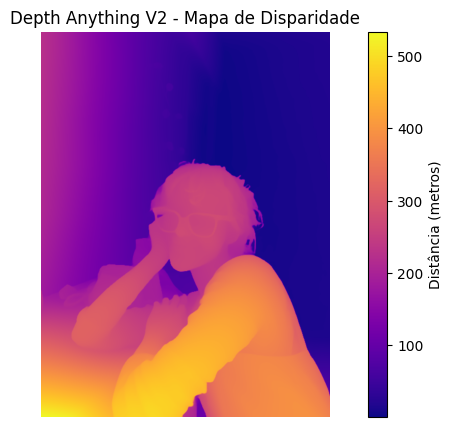

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
# Usamos o mapa de cores 'magma' ou 'plasma' que são ótimos para profundidade
plt.imshow(depth, cmap='plasma')
plt.colorbar(label='Distância (metros)')
plt.title('Depth Anything V2 - Mapa de Disparidade')
plt.axis('off')
plt.show()

In [3]:
import cv2
import numpy as np


# Normalizar para o intervalo [0, 255] para visualização
depth_min = depth.min()
depth_max = depth.max()
depth_normalized = (depth - depth_min) / (depth_max - depth_min)
depth_int = (depth_normalized * 255).astype(np.uint8)

# Aplicar um mapa de cores (opcional, mas ajuda muito no visual)
depth_color = cv2.applyColorMap(depth_int, cv2.COLORMAP_JET)

# Salvar ou mostrar
cv2.imwrite('depth_output.png', depth_color)
# cv2.imshow('Depth', depth_color); cv2.waitKey(0)

True